# Phase 4 — HMM Regime Detection & Dynamic Covariance

**Purpose:** This notebook is *evidentiary*, not exploratory. It shows that the two Phase 4
interventions — HMM regime detection (P2, P3) and the completed covariance ablation ladder
(sample → Ledoit-Wolf → EWMA → DCC-GARCH, P1, P2) — do something real on live data, and reports
the honest result against the Phase 2 hurdle every Phase 4 strategy must beat net of costs,
out-of-sample.

| Problem | What this notebook shows |
|---------|--------------------------|
| **P1** | The full covariance ablation ladder side by side — does each rung actually reduce concentration / improve net Sharpe over the noisy sample estimate? |
| **P2** | Regime detection and dynamic covariance both react to non-stationarity — regimes on real 2020/2022 stress windows, EWMA/DCC-GARCH reacting to a volatility shift a flat sample window averages away |
| **P3** | The HMM's "bear" regime and DCC-GARCH's dynamic correlations are the direct diversification-breakdown story — shown against the known 2022 rate-shock and 2020 COVID windows |
| **P4** | Every strategy compared here runs through the *same* leakage-free engine Phase 2 built and Phase 3/4 proved leak-free end-to-end (`tests/test_phase4_integration.py`) — this notebook does not re-litigate that proof, it reports results from it |

**No-lookahead guarantee — proven elsewhere, not here:** `tests/test_phase4_integration.py`
already proves `RegimeConditionalStrategy` cannot see future feature rows, using the real
strategy (not a toy probe). This notebook trusts that proof and focuses on what the model
*found*, not on re-deriving that it's honest.

**Data caveats carried forward from Phase 1–3 (see `CLAUDE.md` §8.4 for the full list):**
- `full_2021` (9 assets) starts mid-2021 (BVC free-source rolling window); `etf_2017` (5 ETFs)
  covers November 2004→today, restoring COVID-2020 evidence the 9-asset universe lacks.
- `EEM` is stationarity-AMBIGUOUS — the asset most likely to trigger `DCCGarchStrategy`'s
  fallback path (tested, while the released snapshot records zero fallbacks across the evaluated fits).
- `full_2021` is consistently MAD after official BAM conversion and remains unhedged;
  `etf_2017` is consistently USD.
- Regime detection is a **2-state (bull/bear) MVP**, not 3-state (bull/bear/crisis) — see
  `CLAUDE.md` §12 for why, and §7 below for a follow-up on the 3-state question.

> **Actualisation sûre — release MAD/BAM (2026-08-09).** Ce notebook est exécuté sur
> les artefacts finaux versionnés. `full_2021` est exprimé en **MAD**, avec conversion
> causale des niveaux de prix ETF au taux de référence officiel Bank Al-Maghrib, sans
> couverture de change. `etf_2017` est un univers composé uniquement d'ETF en **USD**,
> commence en novembre 2004 et n'est pas modifié par cette correction. Les niveaux de
> Sharpe des deux univers ne sont donc pas comparés entre eux. Les écarts ponctuels sont
> descriptifs; le livrable est un prototype de recherche, ni un conseil, ni un système
> déployé.

In [1]:
from pathlib import Path
import json

SAFE_ROOT = Path.cwd()
if not (SAFE_ROOT / "data" / "gold").exists():
    SAFE_ROOT = SAFE_ROOT.parent
GOLD_RELEASE = SAFE_ROOT / "data" / "gold"

snapshot = json.loads((GOLD_RELEASE / "snapshot_manifest.json").read_text())
currency = json.loads((GOLD_RELEASE / "currency_manifest.json").read_text())
assert snapshot["git_dirty"] is False, "The published snapshot itself must have clean provenance."
assert currency["universes"]["full_2021"]["base_currency"] == "MAD"
assert currency["universes"]["etf_2017"]["base_currency"] == "USD"
print("Published snapshot:", snapshot["git_commit"][:12])
print("full_2021: MAD, official BAM FX, unhedged")
print("etf_2017: USD-only, FX correction not applicable")

Published snapshot: ae87f48207d1
full_2021: MAD, official BAM FX, unhedged
etf_2017: USD-only, FX correction not applicable


## 1. Setup — universes, Phase 3 features, and the Phase 2 hurdle (P4)

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NB_CWD = Path.cwd()
SRC = (NB_CWD.parent / "src") if (NB_CWD.parent / "src").exists() else (NB_CWD / "src")
sys.path.insert(0, str(SRC))

from backtest import build_cost_vector, run_backtest
from metrics import annualized_sharpe, max_drawdown, summarize
from run_phase4 import ROOT, build_strategies, load_features, load_universe
from utils import load_params

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

P = load_params()
BP = P["backtest"]

UNIVERSES = {name: load_universe(path) for name, path in BP["universes"].items()}
FEATURES = {name: load_features(P["ml_features"]["outputs"][name]) for name in BP["universes"]}
HURDLE = json.loads((ROOT / "data" / "gold" / "phase2_hurdle.json").read_text())

for name, df in UNIVERSES.items():
    print(f"{name}: {df.shape[0]} days x {df.shape[1]} assets   "
          f"{df.index.min().date()} -> {df.index.max().date()}   "
          f"Phase 2 hurdle: {HURDLE[name]['strategy']} @ {HURDLE[name]['sharpe_net']:.3f}")

etf_2017: 5656 days x 5 assets   2004-11-19 -> 2026-07-24   Phase 2 hurdle: min_variance @ 0.953
full_2021: 1301 days x 9 assets   2021-07-30 -> 2026-07-24   Phase 2 hurdle: max_sharpe @ 1.069


## 2. Run the full comparison — 4 Phase 2 baselines + 3 Phase 4 strategies (P1–P4)

One pass, both universes: `EqualWeight`, `MinVariance`, `MinVarianceLW`, `MaxSharpe` (Phase 2)
alongside `MinVarianceEWMA`, `DCCGarchStrategy`, `RegimeConditionalStrategy` (Phase 4) — the
exact same `build_strategies()` `src/run_phase4.py` uses, so this notebook's numbers are the
live, reproducible ones, not a hand-copied table. Every later section slices this one result set.

**Runtime note:** dominated by `DCCGarchStrategy`'s per-asset GARCH refits at every rebalance —
expect several minutes, most of it in this cell.

In [3]:
STRATEGIES_BY_UNIVERSE = {name: build_strategies(P) for name in UNIVERSES}
REGIME_STRATEGY = {
    name: next(s for s in strats if s.name == "regime_conditional")
    for name, strats in STRATEGIES_BY_UNIVERSE.items()
}

RESULTS = {}
for uni_name, returns in UNIVERSES.items():
    costs = build_cost_vector(
        returns.columns,
        etf_cost_bps=BP["costs_bps"]["etf"],
        bvc_cost_bps=BP["costs_bps"]["bvc"],
    )
    RESULTS[uni_name] = [
        run_backtest(
            returns, s,
            rebalance_freq=BP["rebalance_freq"],
            min_train_days=BP["min_train_days"],
            cost_bps=costs,
            extras={"features": FEATURES[uni_name]},
            universe_name=uni_name,
            max_weight=BP["max_weight"],
        )
        for s in STRATEGIES_BY_UNIVERSE[uni_name]
    ]
    print(f"{uni_name}: {len(RESULTS[uni_name])} strategies backtested "
          f"({', '.join(r.strategy_name for r in RESULTS[uni_name])}).")

2026-08-09 06:13:42,254 | INFO | backtest | Backtest equal_weight/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.032


2026-08-09 06:13:43,206 | INFO | backtest | Backtest min_variance/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.032


2026-08-09 06:13:44,702 | INFO | backtest | Backtest min_variance_lw/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.032


2026-08-09 06:13:45,538 | INFO | backtest | Backtest max_sharpe/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.038


2026-08-09 06:13:48,960 | INFO | backtest | Backtest min_variance_ewma/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.061


...

2026-08-09 06:41:29,805 | WARNING | regime | regime: only 199 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-08-09 06:41:29,825 | WARNING | regime | regime: only 222 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-08-09 06:41:29,843 | WARNING | regime | regime: only 244 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-08-09 06:41:41,472 | INFO | backtest | Backtest regime_conditional/full_2021: 48 rebalances, OOS 2022-08-01 → 2026-07-24 (1040 days), avg turnover 0.321


full_2021: 7 strategies backtested (equal_weight, min_variance, min_variance_lw, max_sharpe, min_variance_ewma, dcc_garch, regime_conditional).


## 3. The covariance ablation ladder — does dynamic covariance react? (P1, P2)

Four covariance estimators feeding the *same* min-variance objective, plus 1/N as the P1 honest
floor: sample (`MinVariance`) → Ledoit-Wolf shrinkage (`MinVarianceLW`) → EWMA (`MinVarianceEWMA`)
→ DCC-GARCH (`DCCGarchStrategy`). Each rung isolates how much of the P1 problem is fixed by
progressively less naive covariance estimation, before any regime/ML signal is involved.

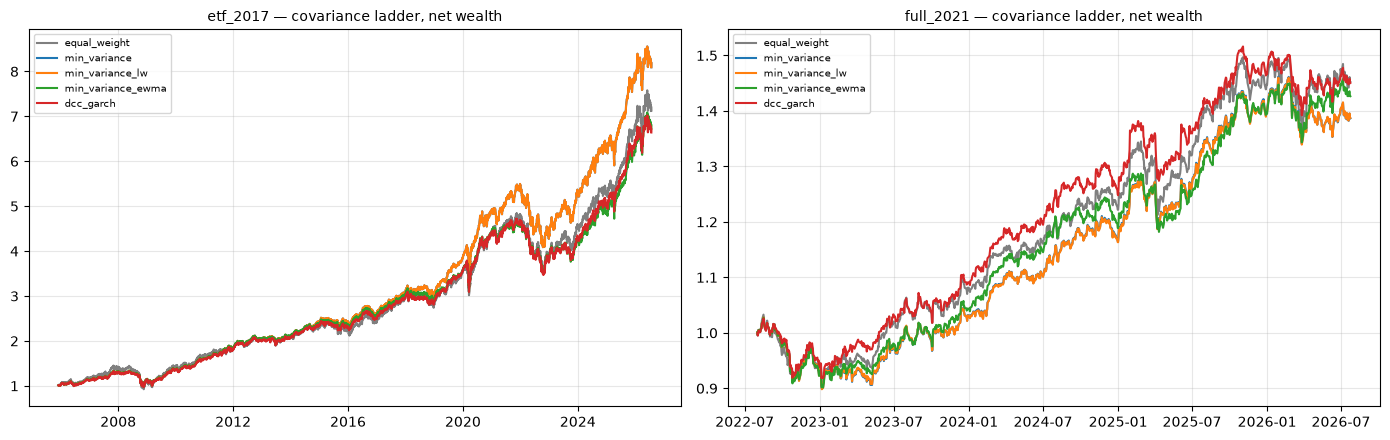

sharpe_net  avg_turnover  max_dd_net
universe  rung                                                   
etf_2017  equal_weight           0.7694        0.0322     -0.3621
          min_variance           0.9525        0.0318     -0.2689
          min_variance_lw        0.9525        0.0318     -0.2689
          min_variance_ewma      0.8942        0.0613     -0.2689
          dcc_garch              0.8880        0.1298     -0.2692
full_2021 equal_weight           0.9528        0.0528     -0.1242
          min_variance           0.8767        0.0769     -0.1257
          min_variance_lw        0.8782        0.0743     -0.1261
          min_variance_ewma      0.9855        0.2079     -0.1221
          dcc_garch              1.0526        0.3781     -0.1046

In [4]:
LADDER_ORDER = ["equal_weight", "min_variance", "min_variance_lw", "min_variance_ewma", "dcc_garch"]
LADDER_COLORS = {
    "equal_weight": "tab:gray", "min_variance": "tab:blue", "min_variance_lw": "tab:orange",
    "min_variance_ewma": "tab:green", "dcc_garch": "tab:red",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, uni_name in zip(axes, UNIVERSES):
    by_name = {r.strategy_name: r for r in RESULTS[uni_name]}
    for name in LADDER_ORDER:
        r = by_name[name]
        wealth = (1 + r.net_returns).cumprod()
        ax.plot(wealth.index, wealth.values, label=name, color=LADDER_COLORS[name])
    ax.set_title(f"{uni_name} — covariance ladder, net wealth", fontsize=10)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

rows = []
for uni_name in UNIVERSES:
    by_name = {r.strategy_name: r for r in RESULTS[uni_name]}
    for name in LADDER_ORDER:
        r = by_name[name]
        rows.append({
            "universe": uni_name, "rung": name,
            "sharpe_net": annualized_sharpe(r.net_returns),
            "avg_turnover": float(r.turnover.mean()),
            "max_dd_net": max_drawdown(r.net_returns),
        })
pd.DataFrame(rows).set_index(["universe", "rung"])

**Does EWMA actually react faster than a flat window?** Same illustration as
`tests/test_strategies.py::test_ewma_reacts_faster_than_lw_to_a_volatility_shift`, now on real
`full_2021` data spanning the calm pre-2022 period into the 2022 rate shock: compare the
annualized volatility a flat sample window estimates for that whole span against what EWMA's
recency-weighted estimate reads at the end of it.

In [5]:
shock_window = UNIVERSES["full_2021"].loc["2021-07-01":"2022-12-31"]
asset = shock_window.columns[0]
halflife = P["covariance_ewma"]["halflife_days"]

sample_var = shock_window.cov().loc[asset, asset] * 252
ewma_var = shock_window.ewm(halflife=halflife).cov().loc[shock_window.index[-1]].loc[asset, asset] * 252

print(f"Annualized volatility estimate for {asset}, spanning calm 2021 into the 2022 shock:")
print(f"  Flat sample window (averages the whole span):        {np.sqrt(sample_var):.1%}")
print(f"  EWMA (halflife={halflife}d, weights the recent shock): {np.sqrt(ewma_var):.1%}")

Annualized volatility estimate for SPY, spanning calm 2021 into the 2022 shock:
  Flat sample window (averages the whole span):        21.4%
  EWMA (halflife=63d, weights the recent shock): 24.0%


## 4. HMM regime detection — what the model found on real data (P2, P3)

`RegimeConditionalStrategy`'s `regime_log` (populated during §2's backtest run, one entry per
rebalance) is the ground truth here — not a re-fit for this notebook. Shaded bands over the
equal-weight wealth curve show which regime the HMM assigned at each rebalance, using only
information available up to that date.

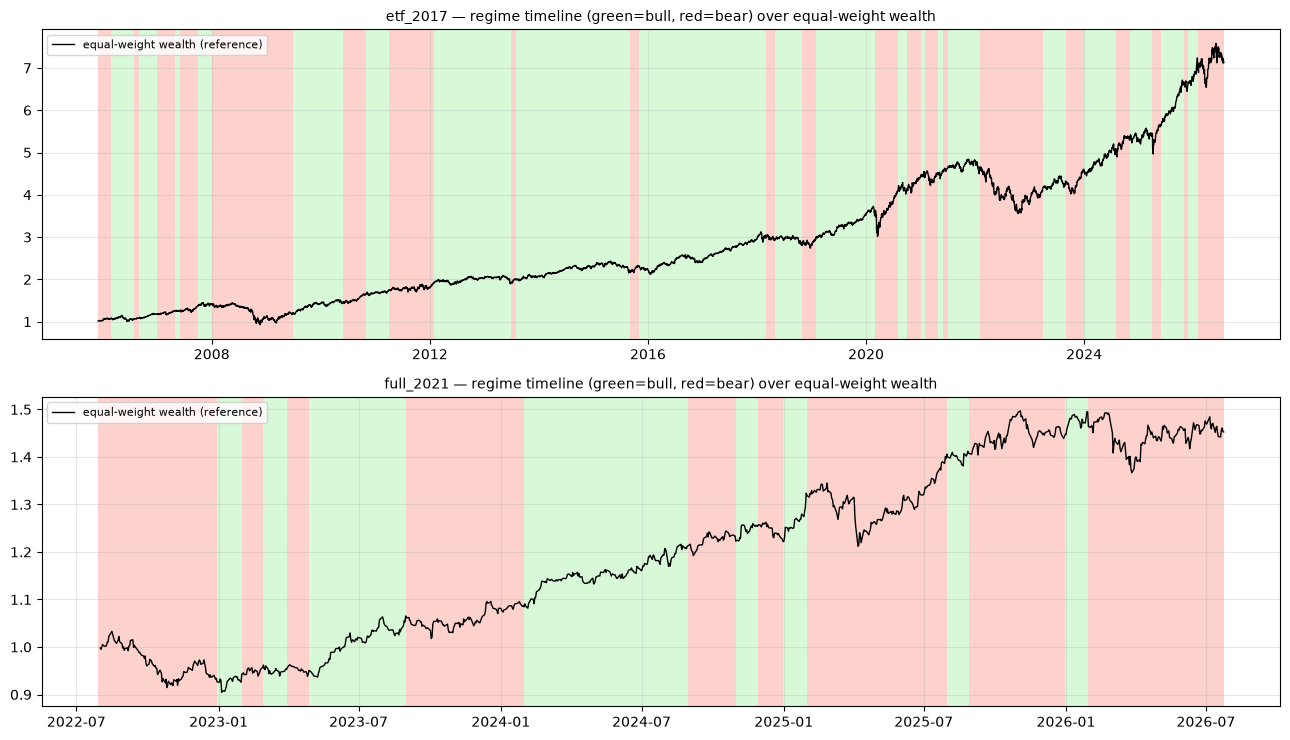

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5))
for ax, uni_name in zip(axes, UNIVERSES):
    ew = next(r for r in RESULTS[uni_name] if r.strategy_name == "equal_weight")
    wealth = (1 + ew.net_returns).cumprod()
    log = REGIME_STRATEGY[uni_name].regime_log

    for i, entry in enumerate(log):
        start = entry["date"]
        end = log[i + 1]["date"] if i + 1 < len(log) else wealth.index[-1]
        color = "lightgreen" if entry["regime"] == "bull" else "salmon"
        ax.axvspan(start, end, color=color, alpha=0.35, lw=0)

    ax.plot(wealth.index, wealth.values, color="black", lw=1, label="equal-weight wealth (reference)")
    ax.set_title(f"{uni_name} — regime timeline (green=bull, red=bear) over equal-weight wealth", fontsize=10)
    ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

In [7]:
rows = []
for uni_name in UNIVERSES:
    log = REGIME_STRATEGY[uni_name].regime_log
    regimes = [e["regime"] for e in log]
    converged_conf = [e["posterior"][e["regime"]] for e in log if e["converged"]]
    rows.append({
        "universe": uni_name,
        "n_rebalances": len(log),
        "pct_bull": regimes.count("bull") / len(log),
        "pct_bear": regimes.count("bear") / len(log),
        "pct_non_converged_fallback": sum(1 for e in log if not e["converged"]) / len(log),
        "avg_confidence_when_converged": float(np.mean(converged_conf)) if converged_conf else float("nan"),
    })
pd.DataFrame(rows).set_index("universe")

,n_rebalances,pct_bull,pct_bear,pct_non_converged_fallback,avg_confidence_when_converged
universe,,,,,
etf_2017,248,0.6169,0.3831,0.0121,0.9798
full_2021,48,0.3542,0.6458,0.0625,0.9871


**Spot-check against known stress windows** (the HMM never saw a labeled "crisis" date — this is
purely what the return/vol/correlation features implied):

In [8]:
def regime_near(log, date_str):
    target = pd.Timestamp(date_str)
    closest = min(log, key=lambda e: abs((e["date"] - target).days))
    return closest["date"].date(), closest["regime"], round(closest["posterior"].get(closest["regime"], float("nan")), 2)


checks = [
    ("etf_2017", "2020-03-31", "COVID crash trough"),
    ("etf_2017", "2022-06-30", "2022 rate shock, mid"),
    ("full_2021", "2022-06-30", "2022 rate shock, mid"),
]
for uni_name, date_str, label in checks:
    date, regime, conf = regime_near(REGIME_STRATEGY[uni_name].regime_log, date_str)
    print(f"{uni_name:10} {label:24} -> nearest rebalance {date}: {regime:4} (confidence {conf})")

etf_2017   COVID crash trough       -> nearest rebalance 2020-03-31: bear (confidence 1.0)
etf_2017   2022 rate shock, mid     -> nearest rebalance 2022-06-30: bear (confidence 1.0)
full_2021  2022 rate shock, mid     -> nearest rebalance 2022-07-29: bear (confidence 0.5)


## 5. Does regime switching actually help? (P2, P3)

`RegimeConditionalStrategy` vs. always running its bull sub-strategy (`MaxSharpe`) or always its
bear sub-strategy (`MinVarianceLW`) — the comparison that shows whether the *switching* adds
anything beyond just picking the better of the two baselines outright.

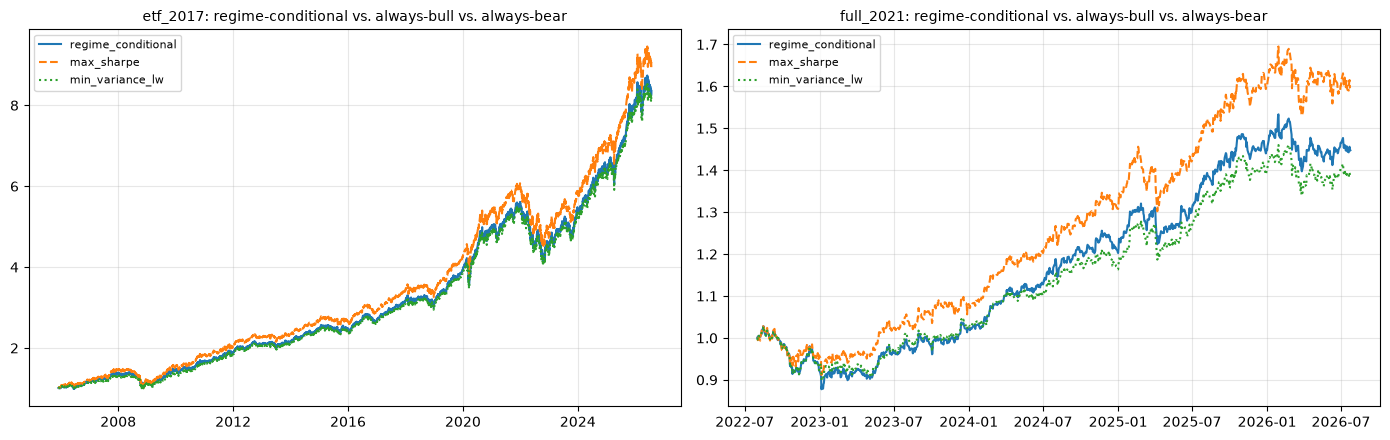

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, uni_name in zip(axes, UNIVERSES):
    by_name = {r.strategy_name: r for r in RESULTS[uni_name]}
    for name, style in [("regime_conditional", "-"), ("max_sharpe", "--"), ("min_variance_lw", ":")]:
        r = by_name[name]
        wealth = (1 + r.net_returns).cumprod()
        ax.plot(wealth.index, wealth.values, style, label=name)
    ax.set_title(f"{uni_name}: regime-conditional vs. always-bull vs. always-bear", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Turnover at regime transitions** — the accepted trade-off from `CLAUDE.md` §12: a hard switch
can spike turnover right at a boundary. Comparing average turnover on switch vs. stable
rebalances quantifies it instead of leaving it as an assertion.

In [10]:
for uni_name in UNIVERSES:
    log = REGIME_STRATEGY[uni_name].regime_log
    r = next(res for res in RESULTS[uni_name] if res.strategy_name == "regime_conditional")

    switch_dates, stable_dates = [], []
    for i, entry in enumerate(log):
        if i == 0:
            continue
        bucket = switch_dates if entry["regime"] != log[i - 1]["regime"] else stable_dates
        bucket.append(entry["date"])

    switch_to = r.turnover[r.turnover.index.isin(switch_dates)]
    stable_to = r.turnover[r.turnover.index.isin(stable_dates)]
    print(f"{uni_name}: {len(switch_dates)} regime switches, avg turnover "
          f"{switch_to.mean():.3f} vs. {len(stable_dates)} stable rebalances, avg turnover "
          f"{stable_to.mean():.3f}  ({'higher' if switch_to.mean() > stable_to.mean() else 'not higher'} at switches)")

etf_2017: 40 regime switches, avg turnover 0.168 vs. 207 stable rebalances, avg turnover 0.030  (higher at switches)
full_2021: 16 regime switches, avg turnover 0.755 vs. 31 stable rebalances, avg turnover 0.075  (higher at switches)


## 6. Full scoreboard — every Phase 4 strategy vs. the Phase 2 hurdle (P1, P4)

Same `metrics.summarize()` panel Phase 2 used, now over all 7 strategies with a shared DSR trial
pool per universe (the N-honesty rule from `src/run_phase4.py`'s docstring) — the exact numbers
`data/gold/phase4_results.json` was built from.

In [11]:
PHASE4_STRATEGY_NAMES = {"min_variance_ewma", "dcc_garch", "regime_conditional"}

panels = []
for uni_name, results in RESULTS.items():
    trial_sharpes = [
        float(r.net_returns.mean() / r.net_returns.std()) if r.net_returns.std() > 0 else 0.0
        for r in results
    ]
    ew_net = next(r for r in results if r.strategy_name == "equal_weight").net_returns
    for r in results:
        panel = summarize(
            r.net_returns, r.gross_returns, r.turnover,
            benchmark_net=ew_net if r.strategy_name != "equal_weight" else None,
            trial_sharpes=trial_sharpes, risk_free_annual=BP["risk_free_annual"],
        )
        panel["universe"], panel["strategy"] = uni_name, r.strategy_name
        panel["is_phase4"] = r.strategy_name in PHASE4_STRATEGY_NAMES
        panels.append(panel)

metrics_table = pd.DataFrame(panels).set_index(["universe", "strategy"])
metrics_table[["ann_return_net", "sharpe_net", "max_drawdown_net", "avg_turnover", "dsr_net", "n_trials", "is_phase4"]]

ann_return_net  sharpe_net  max_drawdown_net  \
universe  strategy                                                           
etf_2017  equal_weight                0.0962      0.7694           -0.3621   
          min_variance                0.1028      0.9525           -0.2689   
          min_variance_lw             0.1028      0.9525           -0.2689   
          max_sharpe                  0.1079      0.9120           -0.3280   
          min_variance_ewma           0.0933      0.8942           -0.2689   
          dcc_garch                   0.0926      0.8880           -0.2692   
          regime_conditional          0.1038      0.9371           -0.2689   
full_2021 equal_weight                0.0947      0.9528           -0.1242   
          min_variance                0.0824      0.8767           -0.1257   
          min_variance_lw             0.0826      0.8782           -0.1261   
          max_sharpe                  0.1199      1.0690           -0.1131   
          min_variance_ewma           0.0899      0.9855           -0.1221   
          dcc_garch                   0.0943      1.0526           -0.1046   
          regime_conditional          0.0938      0.9571           -0.1462   

                              avg_turnover  dsr_net  n_trials  is_phase4  
universe  strategy                                                        
etf_2017  equal_weight              0.0322   0.9992    7.0000      False  
          min_variance              0.0318   1.0000    7.0000      False  
          min_variance_lw           0.0318   1.0000    7.0000      False  
          max_sharpe                0.0380   0.9999    7.0000      False  
          min_variance_ewma         0.0613   0.9999    7.0000       True  
          dcc_garch                 0.1298   0.9999    7.0000       True  
          regime_conditional        0.0561   1.0000    7.0000       True  
full_2021 equal_weight              0.0528   0.9557    7.0000      False  
          min_variance              0.0769   0.9394    7.0000      False  
          min_variance_lw           0.0743   0.9397    7.0000      False  
          max_sharpe                0.1444   0.9733    7.0000      False  
          min_variance_ewma         0.2079   0.9620    7.0000       True  
          dcc_garch                 0.3781   0.9729    7.0000       True  
          regime_conditional        0.3212   0.9560    7.0000       True

In [12]:
PHASE4_RESULTS = json.loads((ROOT / "data" / "gold" / "phase4_results.json").read_text())
for uni_name, entry in PHASE4_RESULTS.items():
    verdict = "BEATS" if entry["beats_phase2_hurdle"] else "does not beat"
    print(f"{uni_name}: best is {entry['strategy']} (net Sharpe {entry['sharpe_net']:.4f}) "
          f"-- {verdict} the Phase 2 hurdle ({HURDLE[uni_name]['strategy']} @ {HURDLE[uni_name]['sharpe_net']:.4f})")

etf_2017: best is min_variance (net Sharpe 0.9525) -- does not beat the Phase 2 hurdle (min_variance @ 0.9525)
full_2021: best is max_sharpe (net Sharpe 1.0690) -- does not beat the Phase 2 hurdle (max_sharpe @ 1.0690)


## 7. Why didn't `etf_2017` respond to regime/covariance ML? (P1, P2, P4)

The honest negative result from §6 deserves investigation, not a shrug. Two candidate
explanations, checked directly against this run's own data rather than speculated about:

In [13]:
for uni_name in UNIVERSES:
    rc = next(r for r in RESULTS[uni_name] if r.strategy_name == "regime_conditional")
    best_baseline = next(r for r in RESULTS[uni_name] if r.strategy_name == HURDLE[uni_name]["strategy"])
    cost_drag_rc = float((rc.gross_returns - rc.net_returns).sum())
    cost_drag_baseline = float((best_baseline.gross_returns - best_baseline.net_returns).sum())

    print(f"=== {uni_name} ===")
    print(f"  History: {UNIVERSES[uni_name].shape[0]} trading days "
          f"({UNIVERSES[uni_name].index.min().date()} -> {UNIVERSES[uni_name].index.max().date()})")
    print(f"  Phase 2 hurdle ({HURDLE[uni_name]['strategy']}) gross Sharpe: "
          f"{annualized_sharpe(best_baseline.gross_returns):.3f}, net: {annualized_sharpe(best_baseline.net_returns):.3f}, "
          f"cumulative cost drag: {cost_drag_baseline:.4f}")
    print(f"  regime_conditional gross Sharpe: {annualized_sharpe(rc.gross_returns):.3f}, "
          f"net: {annualized_sharpe(rc.net_returns):.3f}, cumulative cost drag: {cost_drag_rc:.4f}, "
          f"avg turnover: {float(rc.turnover.mean()):.3f}")
    print()

=== etf_2017 ===
  History: 5656 trading days (2004-11-19 -> 2026-07-24)
  Phase 2 hurdle (min_variance) gross Sharpe: 0.956, net: 0.953, cumulative cost drag: 0.0079
  regime_conditional gross Sharpe: 0.943, net: 0.937, cumulative cost drag: 0.0139, avg turnover: 0.056

=== full_2021 ===
  History: 1301 trading days (2021-07-30 -> 2026-07-24)
  Phase 2 hurdle (max_sharpe) gross Sharpe: 1.104, net: 1.069, cumulative cost drag: 0.0157
  regime_conditional gross Sharpe: 1.037, net: 0.957, cumulative cost drag: 0.0319, avg turnover: 0.321



**Reading the current run.** The ETF-only universe has substantially deeper history, while
`full_2021` begins in 2021 and is evaluated in MAD. The covariance/regime family does not replace
the classical winner on either released universe. This is an observed ranking, not a paired test
of `regime_conditional` against `max_sharpe`. The fixed 25% cap is near-determining with five ETF
assets, so the ETF result also measures the constraint as much as the estimator.

## 8. Summary — what Phase 4 establishes in the final release

- HMM regime detection and the covariance ablation ladder run through the same causal engine.
- On the released MAD/BAM snapshot, neither universe's best point estimate is a Phase 4 strategy;
  the canonical artifact below is the authority.
- Telemetry, not a label, establishes whether a fallback occurred; the release records zero
  fallbacks across the evaluated fits, without claiming that fallback paths can never fire.
- The result is descriptive and does not establish superiority or equivalence.

In [14]:
canonical = json.loads((ROOT / "data" / "gold" / "phase4_results.json").read_text())
for universe, results in RESULTS.items():
    winner = max(results, key=lambda r: annualized_sharpe(r.net_returns))
    measured = annualized_sharpe(winner.net_returns)
    assert winner.strategy_name == canonical[universe]["strategy"]
    assert abs(measured - canonical[universe]["sharpe_net"]) < 5e-4
    print(f"{universe}: {winner.strategy_name} {measured:.4f} — matches canonical Gold")

etf_2017: min_variance 0.9525 — matches canonical Gold
full_2021: max_sharpe 1.0690 — matches canonical Gold
